   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00
File found: True
Shape: (51, 9)
                 Arc  Start onChapter  TotalChapters  TotalPages Manga%  \
0   Romance Dawn Arc                1              7         178   0.9%   
1    Orange Town Arc                8             14         273   1.4%   
2  Syrup Village Arc               22             20         396   2.0%   
3        Baratie Arc               42             27         514   2.6%   
4    Arlong Park Arc               69             27         514   2.6%   

   Start onEpisode  TotalEpisodes  Total

100%|██████████| 13/13 [00:00<00:00, 162.41it/s]


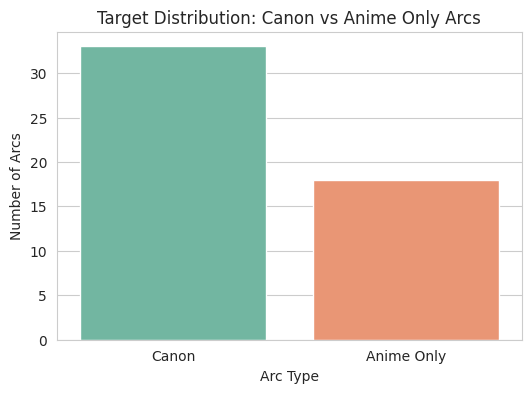

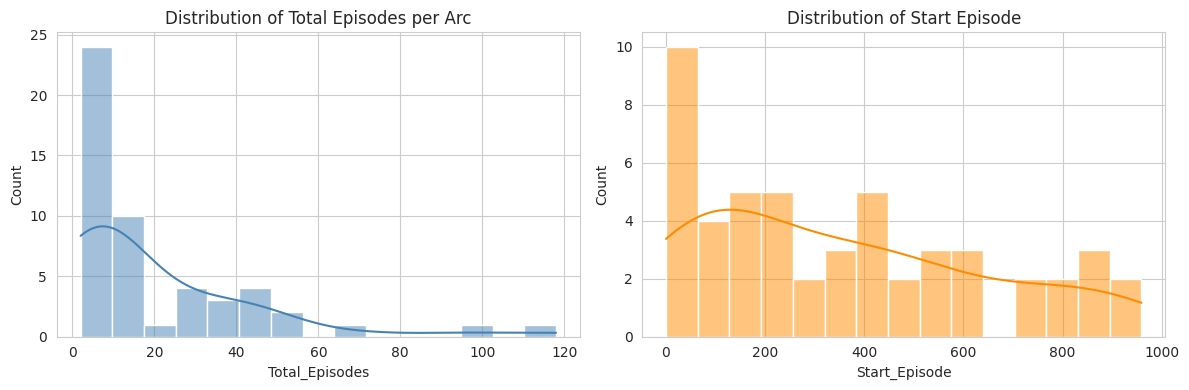

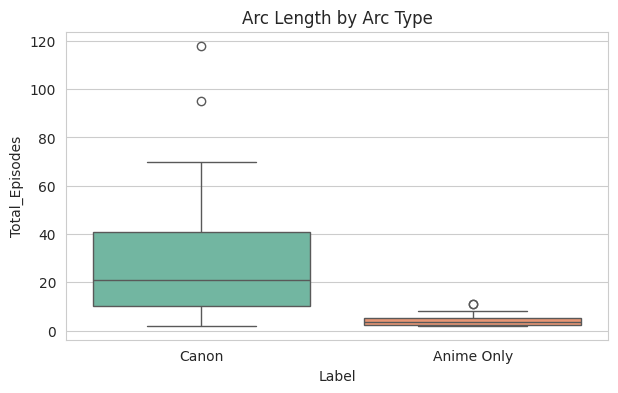

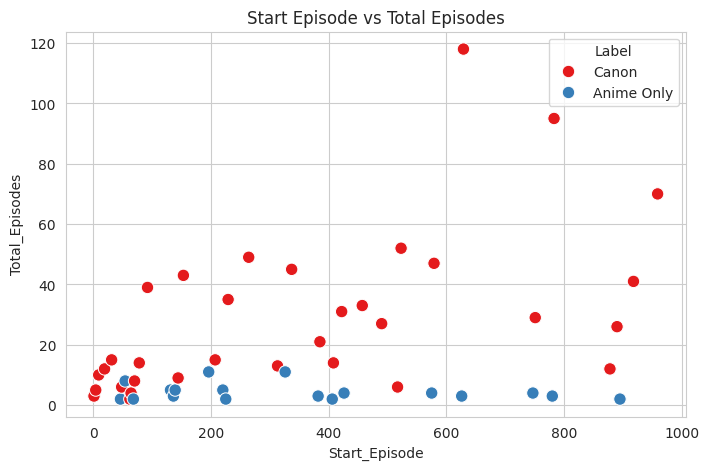

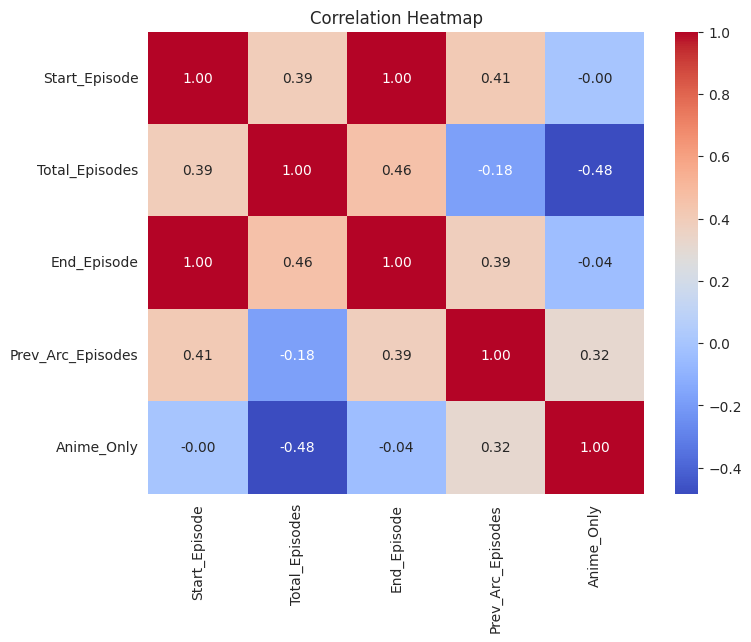

           Model  Accuracy  Precision  Recall      F1  ROC_AUC  OOB_Score  \
0  Decision Tree    0.8182     0.6667    1.00  0.8000   0.8571        NaN   
1        Bagging    0.7273     0.6000    0.75  0.6667   0.8571      0.900   
2  Random Forest    0.7273     0.6000    0.75  0.6667   0.8036      0.875   

   OOB_Error  
0        NaN  
1      0.100  
2      0.125  
Decision Tree 5-Fold CV Accuracy: 0.8436 +/- 0.0785
Bagging 5-Fold CV Accuracy: 0.8436 +/- 0.0785
Random Forest 5-Fold CV Accuracy: 0.8236 +/- 0.0742


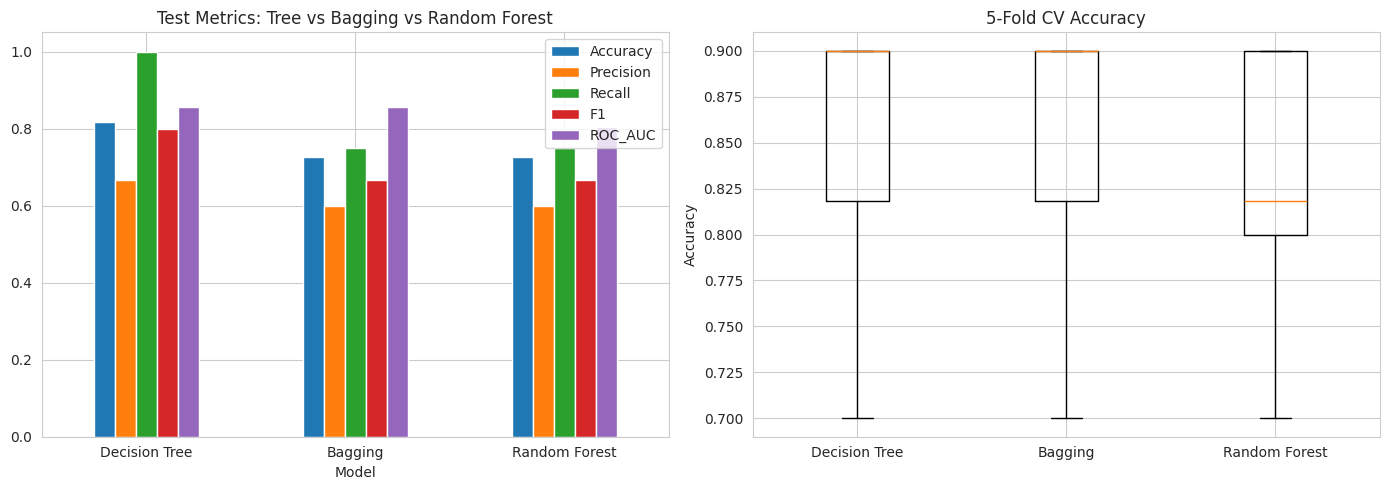

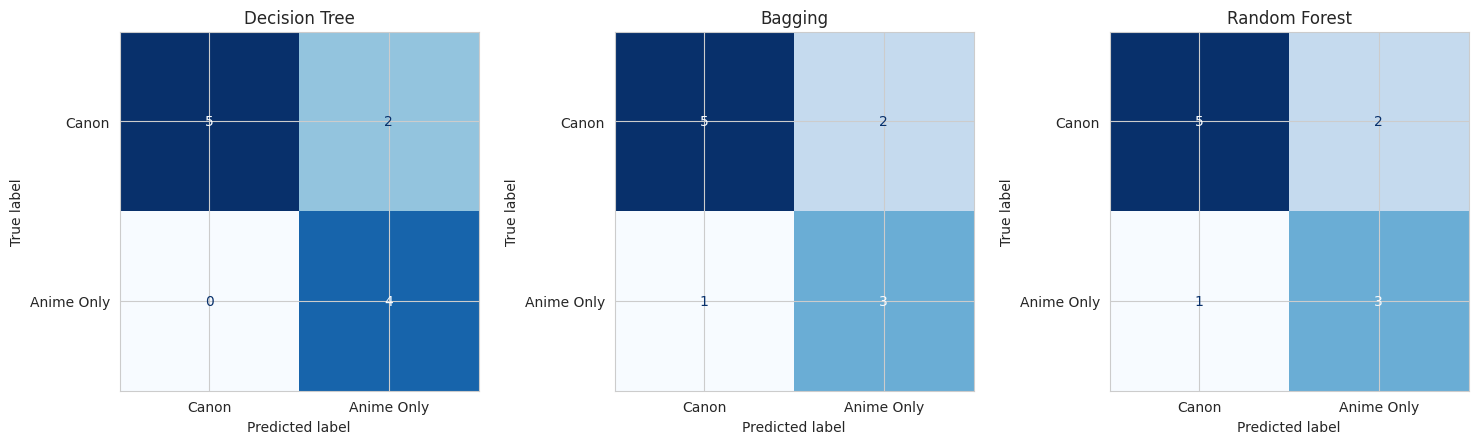

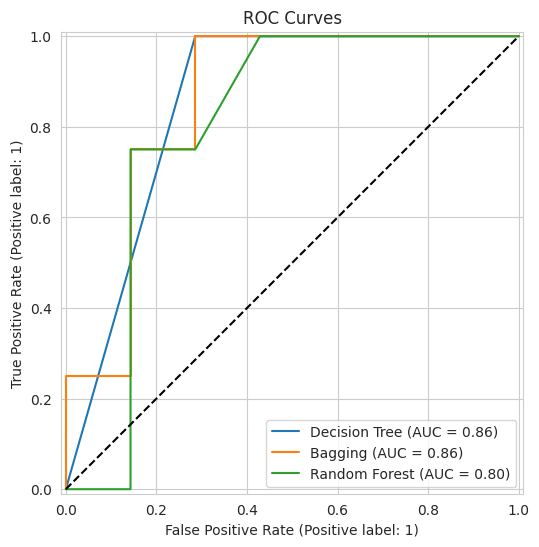

Original Samples: 40
Bootstrap Samples: 40
Unique Samples in Bootstrap: 27
OOB Samples: 13
Expected OOB Fraction: 0.3632


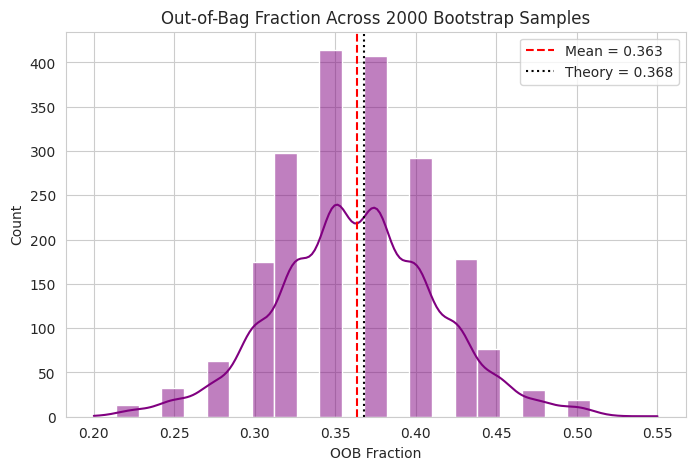

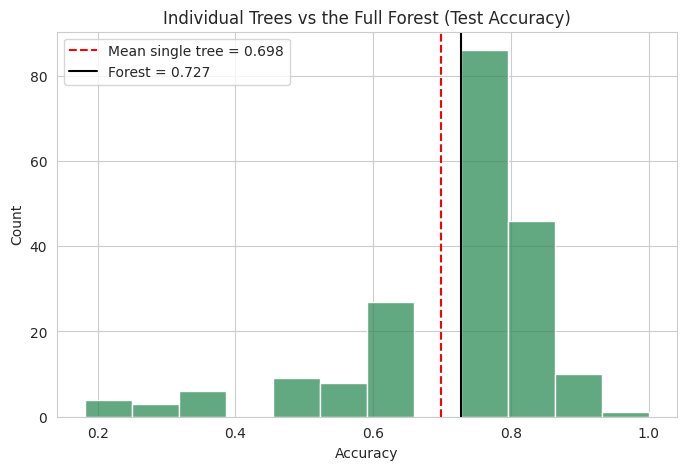

  max_features  Resolved_Features  OOB_Score  OOB_Error  Test_Acc
0         sqrt                  2      0.875      0.125    0.7273
1         log2                  2      0.875      0.125    0.7273
2          0.5                  2      0.875      0.125    0.7273
3          1.0                  4      0.875      0.125    0.7273


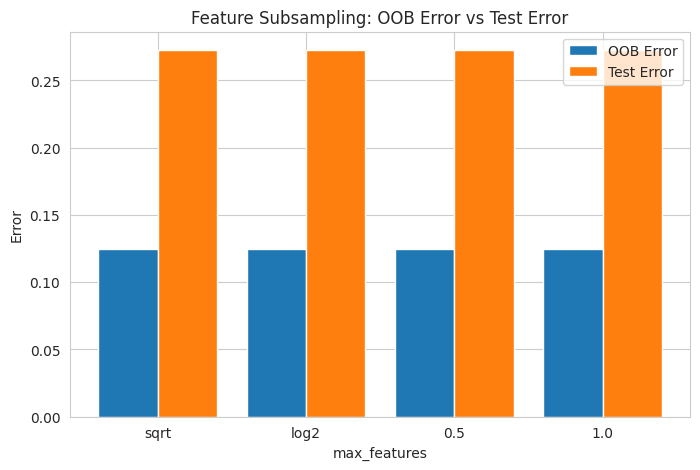

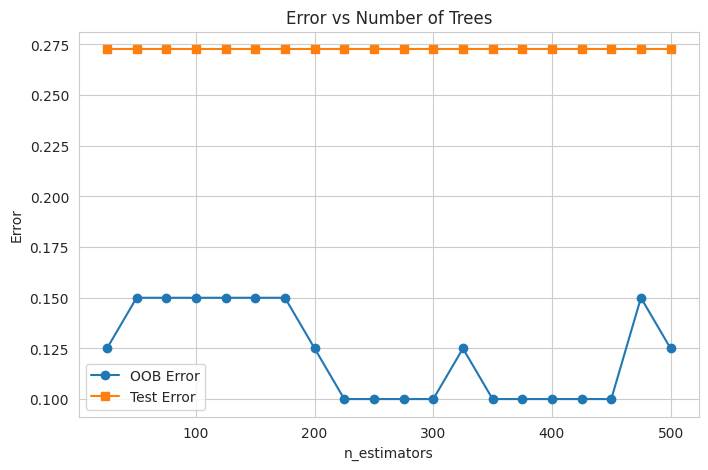

             Feature  Impurity_Importance  Permutation_Importance
1     Total_Episodes               0.5725                  0.2242
3  Prev_Arc_Episodes               0.1710                  0.0000
0      Start_Episode               0.1287                  0.0000
2        End_Episode               0.1278                  0.0000


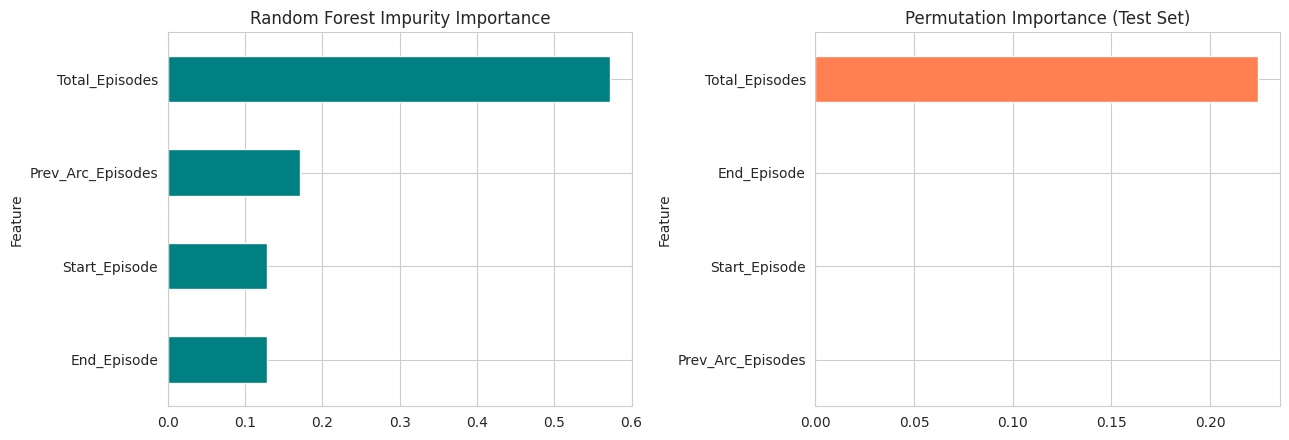

              precision    recall  f1-score   support

       Canon       0.83      0.71      0.77         7
  Anime Only       0.60      0.75      0.67         4

    accuracy                           0.73        11
   macro avg       0.72      0.73      0.72        11
weighted avg       0.75      0.73      0.73        11



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip -q install -U fg-data-profiling

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files
from data_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PATH = "/content/OnePieceArcs.csv"
print("File found:", os.path.exists(PATH))

df = pd.read_csv(PATH)

print("Shape:", df.shape)
print(df.head())
print(df.tail())
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.describe())
print(df.sample(5, random_state=42))

df = df.rename(columns={
    "Start onChapter": "Start_Chapter",
    "TotalChapters": "Total_Chapters",
    "TotalPages": "Total_Pages",
    "Manga%": "Manga_Pct",
    "Start onEpisode": "Start_Episode",
    "TotalEpisodes": "Total_Episodes",
    "TotalMinutes(avg 24)": "Total_Minutes",
    "Anime%": "Anime_Pct"
})

for col in ["Manga_Pct", "Anime_Pct"]:
    df[col] = df[col].str.rstrip("%").astype(float)

df["Anime_Only"] = (df["Total_Chapters"] == 0).astype(int)
df["Label"] = df["Anime_Only"].map({0: "Canon", 1: "Anime Only"})
df["End_Episode"] = df["Start_Episode"] + df["Total_Episodes"] - 1
df["Prev_Arc_Episodes"] = df["Total_Episodes"].shift(1).fillna(0)

FEATURES = ["Start_Episode", "Total_Episodes", "End_Episode", "Prev_Arc_Episodes"]
CLASS_NAMES = ["Canon", "Anime Only"]

X = df[FEATURES]
y = df["Anime_Only"]

print(df[["Arc", "Total_Chapters", "Total_Episodes", "Anime_Only", "Label"]].head(10))
print(df["Label"].value_counts())
print(df["Label"].value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class balance:", y_train.value_counts().to_dict())
print("Test class balance:", y_test.value_counts().to_dict())

pdf = PdfPages("Exp9_EDA_Report.pdf")

def save():
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()

profile = ProfileReport(df, title="One Piece Arcs EDA - Exp 9 Random Forest", explorative=True, progress_bar=False)
profile.to_file("Exp9_Profile_Report.html")

plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, order=CLASS_NAMES, palette="Set2")
plt.title("Target Distribution: Canon vs Anime Only Arcs")
plt.xlabel("Arc Type")
plt.ylabel("Number of Arcs")
save()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Total_Episodes"], bins=15, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Total Episodes per Arc")
sns.histplot(df["Start_Episode"], bins=15, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Start Episode")
plt.tight_layout()
save()

plt.figure(figsize=(7, 4))
sns.boxplot(x="Label", y="Total_Episodes", data=df, order=CLASS_NAMES, palette="Set2")
plt.title("Arc Length by Arc Type")
save()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Start_Episode", y="Total_Episodes", hue="Label", hue_order=CLASS_NAMES, s=80, palette="Set1")
plt.title("Start Episode vs Total Episodes")
save()

plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES + ["Anime_Only"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
save()

tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=200, bootstrap=True, oob_score=True, random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=200, max_features="sqrt", bootstrap=True, oob_score=True, random_state=42).fit(X_train, y_train)

ensemble = {"Decision Tree": tree, "Bagging": bag, "Random Forest": rf}

rows = []
for name, m in ensemble.items():
    pred = m.predict(X_test)
    oob = getattr(m, "oob_score_", np.nan)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, m.predict_proba(X_test)[:, 1]),
        "OOB_Score": oob,
        "OOB_Error": 1 - oob
    })
model_results = pd.DataFrame(rows).round(4)
print(model_results)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {name: cross_val_score(m, X, y, cv=cv) for name, m in ensemble.items()}
for name, s in cv_scores.items():
    print(name, "5-Fold CV Accuracy: %.4f +/- %.4f" % (s.mean(), s.std()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Test Metrics: Tree vs Bagging vs Random Forest")
axes[0].set_ylim(0, 1.05)
axes[1].boxplot(list(cv_scores.values()), labels=list(cv_scores.keys()))
axes[1].set_title("5-Fold CV Accuracy")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
save()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, m) in zip(axes, ensemble.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, display_labels=CLASS_NAMES, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
save()

fig, ax = plt.subplots(figsize=(7, 6))
for name, m in ensemble.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--")
ax.set_title("ROC Curves")
save()

n = len(X_train)
rng = np.random.default_rng(42)
idx = rng.integers(0, n, n)
unique_n = len(np.unique(idx))
print("Original Samples:", n)
print("Bootstrap Samples:", len(idx))
print("Unique Samples in Bootstrap:", unique_n)
print("OOB Samples:", n - unique_n)
print("Expected OOB Fraction:", round((1 - 1 / n) ** n, 4))

oob_fractions = []
for _ in range(2000):
    s = rng.integers(0, n, n)
    oob_fractions.append(1 - len(np.unique(s)) / n)

plt.figure(figsize=(8, 5))
sns.histplot(oob_fractions, bins=25, kde=True, color="purple")
plt.axvline(np.mean(oob_fractions), color="red", linestyle="--", label="Mean = %.3f" % np.mean(oob_fractions))
plt.axvline(0.368, color="black", linestyle=":", label="Theory = 0.368")
plt.title("Out-of-Bag Fraction Across 2000 Bootstrap Samples")
plt.xlabel("OOB Fraction")
plt.legend()
save()

tree_acc = [t.score(X_test.values, y_test) for t in rf.estimators_]
plt.figure(figsize=(8, 5))
sns.histplot(tree_acc, bins=12, color="seagreen")
plt.axvline(np.mean(tree_acc), color="red", linestyle="--", label="Mean single tree = %.3f" % np.mean(tree_acc))
plt.axvline(rf.score(X_test, y_test), color="black", linestyle="-", label="Forest = %.3f" % rf.score(X_test, y_test))
plt.title("Individual Trees vs the Full Forest (Test Accuracy)")
plt.xlabel("Accuracy")
plt.legend()
save()

rows = []
for mf in ["sqrt", "log2", 0.5, 1.0]:
    m = RandomForestClassifier(n_estimators=200, max_features=mf, oob_score=True, random_state=42).fit(X_train, y_train)
    rows.append({"max_features": str(mf), "Resolved_Features": m.estimators_[0].max_features_, "OOB_Score": m.oob_score_, "OOB_Error": 1 - m.oob_score_, "Test_Acc": m.score(X_test, y_test)})
mf_results = pd.DataFrame(rows).round(4)
print(mf_results)

plt.figure(figsize=(8, 5))
x_pos = np.arange(len(mf_results))
plt.bar(x_pos - 0.2, mf_results["OOB_Error"], width=0.4, label="OOB Error")
plt.bar(x_pos + 0.2, 1 - mf_results["Test_Acc"], width=0.4, label="Test Error")
plt.xticks(x_pos, mf_results["max_features"])
plt.xlabel("max_features")
plt.ylabel("Error")
plt.title("Feature Subsampling: OOB Error vs Test Error")
plt.legend()
save()

tree_counts = list(range(25, 501, 25))
oob_err, test_err = [], []
for k in tree_counts:
    m = RandomForestClassifier(n_estimators=k, max_features="sqrt", oob_score=True, random_state=42).fit(X_train, y_train)
    oob_err.append(1 - m.oob_score_)
    test_err.append(1 - m.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, oob_err, marker="o", label="OOB Error")
plt.plot(tree_counts, test_err, marker="s", label="Test Error")
plt.xlabel("n_estimators")
plt.ylabel("Error")
plt.title("Error vs Number of Trees")
plt.legend()
save()

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
imp_df = pd.DataFrame({
    "Feature": FEATURES,
    "Impurity_Importance": rf.feature_importances_,
    "Permutation_Importance": perm.importances_mean
}).sort_values("Impurity_Importance", ascending=False).round(4)
print(imp_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
imp_df.sort_values("Impurity_Importance").plot(x="Feature", y="Impurity_Importance", kind="barh", ax=axes[0], color="teal", legend=False)
axes[0].set_title("Random Forest Impurity Importance")
imp_df.sort_values("Permutation_Importance").plot(x="Feature", y="Permutation_Importance", kind="barh", ax=axes[1], color="coral", legend=False)
axes[1].set_title("Permutation Importance (Test Set)")
plt.tight_layout()
save()

print(classification_report(y_test, rf.predict(X_test), target_names=CLASS_NAMES, zero_division=0))

pdf.close()
files.download("Exp9_Profile_Report.html")
files.download("Exp9_EDA_Report.pdf")